# Clean ACN Data

Cleans the ACN CSVs from Data_Acquisition.

Input files:

```text
Data/ACN/acquired/<site>_2019_sessions.csv
```

## 1. Setup

In [2]:
from datetime import datetime, timezone
from email.utils import parsedate_to_datetime
from pathlib import Path
from typing import Any
import ast as python_ast
import hashlib
import json
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 140)


def find_project_root(start: Path | None = None) -> Path:
    current = Path(start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "Data").exists() and (candidate / "Notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the SEND-EV project root. "
        "Open this notebook from a repository containing Data/ and Notebooks/."
    )


ROOT = find_project_root()
ACN_DIR = ROOT / "Data" / "ACN"
ACQUIRED_DIR = ACN_DIR / "acquired"
PROCESSED_DIR = ACN_DIR / "processed"
RESULTS_DIR = ROOT / "Data" / "Results"
FIGURES_DIR = ROOT / "Figures"

for directory in [PROCESSED_DIR, RESULTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SITES = ("caltech", "jpl", "office001")

# Require all sites.
# Allow quick tests.
REQUIRE_ALL_SITES = True

SITE_TIMEZONE = "America/Los_Angeles"

DEFAULT_CHARGER_POWER_KW = {
    "caltech": 6.6,
    "jpl": 6.6,
    "office001": 6.6,
}

CHARGING_EFFICIENCY = 0.90
MIN_DWELL_HOURS = 0.10
MAX_DWELL_HOURS = 48.0
DUPLICATE_KEEP = "last"

# Energy target.
#   "delivered"
#   "requested_else_delivered"
ENERGY_REQUIREMENT_POLICY = "delivered"

EXCLUDE_INFEASIBLE_FROM_OPTIMISATION = True

print("Project root:", ROOT)
print("Python:", sys.executable)
print("Python version:", platform.python_version())
print("Input directory:", ACQUIRED_DIR)

Project root: /Users/mac/Send-Ev-Project/SEND-EV-Project
Python: /Users/mac/Library/Caches/pypoetry/virtualenvs/send-ev-project-11oc5mOD-py3.12/bin/python
Python version: 3.12.13
Input directory: /Users/mac/Send-Ev-Project/SEND-EV-Project/Data/ACN/acquired


## 2. Load Files

In [3]:
REQUIRED_COLUMNS = {
    "session_id",
    "site",
    "connection_time_utc",
    "disconnect_time_utc",
    "kwh_delivered",
}

OPTIONAL_COLUMNS = {
    "record_id",
    "station_id",
    "space_id",
    "cluster_id",
    "user_id",
    "done_charging_time_utc",
    "source_max_power_kw",
    "user_inputs_json",
    "source_file",
    "source_row_number",
    "session_id_derived",
    "extraction_start_utc",
    "extraction_end_utc_exclusive",
}


def parse_utc(values: pd.Series) -> pd.Series:
    try:
        return pd.to_datetime(
            values,
            errors="coerce",
            utc=True,
            format="mixed",
        )
    except TypeError:
        return pd.to_datetime(
            values,
            errors="coerce",
            utc=True,
        )


input_frames: list[pd.DataFrame] = []
validation_rows: list[dict[str, Any]] = []

for site in SITES:
    path = ACQUIRED_DIR / f"{site}_2019_sessions.csv"

    if not path.exists():
        validation_rows.append(
            {
                "site": site,
                "file": path.name,
                "exists": False,
                "rows": 0,
                "missing_required_columns": ", ".join(sorted(REQUIRED_COLUMNS)),
                "arrival_parse_share": 0.0,
                "departure_parse_share": 0.0,
                "energy_numeric_share": 0.0,
                "usable": False,
            }
        )
        continue

    frame = pd.read_csv(path)
    frame.columns = [
        str(column).replace("\ufeff", "").strip()
        for column in frame.columns
    ]

    missing_columns = sorted(REQUIRED_COLUMNS - set(frame.columns))

    if missing_columns:
        arrival_share = 0.0
        departure_share = 0.0
        energy_share = 0.0
        usable = False
    else:
        arrival_share = (
            float(parse_utc(frame["connection_time_utc"]).notna().mean())
            if len(frame)
            else 0.0
        )
        departure_share = (
            float(parse_utc(frame["disconnect_time_utc"]).notna().mean())
            if len(frame)
            else 0.0
        )
        energy_share = (
            float(
                pd.to_numeric(
                    frame["kwh_delivered"],
                    errors="coerce",
                ).notna().mean()
            )
            if len(frame)
            else 0.0
        )
        usable = bool(
            len(frame) > 0
            and min(arrival_share, departure_share, energy_share) > 0
        )

    validation_rows.append(
        {
            "site": site,
            "file": path.name,
            "exists": True,
            "rows": len(frame),
            "missing_required_columns": ", ".join(missing_columns),
            "arrival_parse_share": arrival_share,
            "departure_parse_share": departure_share,
            "energy_numeric_share": energy_share,
            "usable": usable,
        }
    )

    if usable:
        frame["site"] = site

        for column in OPTIONAL_COLUMNS:
            if column not in frame.columns:
                frame[column] = np.nan

        input_frames.append(frame)

input_validation = pd.DataFrame(validation_rows)
display(input_validation)

input_validation_path = RESULTS_DIR / "acn_input_validation.csv"
input_validation.to_csv(input_validation_path, index=False)
print("Input validation saved:", input_validation_path)

usable_sites = input_validation.loc[
    input_validation["usable"],
    "site",
].tolist()

missing_sites = [
    site for site in SITES if site not in usable_sites
]

if REQUIRE_ALL_SITES and missing_sites:
    raise RuntimeError(
        "Notebook 11A has not produced usable standardised files for: "
        + ", ".join(missing_sites)
        + ". Run Notebook 11A first and review its acquisition manifest."
    )

if not input_frames:
    raise RuntimeError(
        "No usable standardised acquisition files were found in "
        "Data/ACN/acquired."
    )

raw = pd.concat(input_frames, ignore_index=True, sort=False)

print("Loaded rows:", f"{len(raw):,}")
print("Usable sites:", ", ".join(usable_sites))
print("Missing sites:", ", ".join(missing_sites) if missing_sites else "None")
display(raw.head())

,site,file,exists,rows,missing_required_columns,arrival_parse_share,departure_parse_share,energy_numeric_share,usable
0,caltech,caltech_2019_sessions.csv,True,10617,,1.0,1.0,1.0,True
1,jpl,jpl_2019_sessions.csv,True,17411,,1.0,1.0,1.0,True
2,office001,office001_2019_sessions.csv,True,922,,1.0,1.0,1.0,True


Input validation saved: /Users/mac/Send-Ev-Project/SEND-EV-Project/Data/Results/acn_input_validation.csv
Loaded rows: 28,950
Usable sites: caltech, jpl, office001
Missing sites: None


,session_id,record_id,site,station_id,space_id,cluster_id,user_id,connection_time_utc,disconnect_time_utc,done_charging_time_utc,kwh_delivered,source_max_power_kw,user_inputs_json,source_file,source_row_number,extraction_start_utc,extraction_end_utc_exclusive,session_id_derived
0,2_39_78_363_2019-01-07 23:35:24.653618,5c49152ff9af8b42baad53f2,caltech,2-39-78-363,CA-320,39,676.0,2019-01-07T23:35:25+00:00,2019-01-08T05:26:04+00:00,2019-01-08T05:25:55+00:00,16.426,NaN,"[{""userID"": 676, ""milesRequested"": 50, ""WhPerMile"": 364, ""minutesAvailable"": 348, ""modifiedAt"": ""Mon, 07 Jan 2019 23:35:26 GMT"", ""paymen...",caltech_2019_raw.jsonl,0,2019-01-01T00:00:00+00:00,2020-01-01T00:00:00+00:00,False
1,2_39_127_19_2019-01-07 23:31:27.973382,5c49152ff9af8b42baad53f1,caltech,2-39-127-19,CA-309,39,1309.0,2019-01-07T23:31:28+00:00,2019-01-08T00:03:51+00:00,2019-01-08T00:03:46+00:00,2.754,NaN,"[{""userID"": 1309, ""milesRequested"": 60, ""WhPerMile"": 450, ""minutesAvailable"": 55, ""modifiedAt"": ""Mon, 07 Jan 2019 23:34:46 GMT"", ""paymen...",caltech_2019_raw.jsonl,1,2019-01-01T00:00:00+00:00,2020-01-01T00:00:00+00:00,False
2,2_39_78_360_2019-01-07 22:26:48.771620,5c49152ff9af8b42baad53f0,caltech,2-39-78-360,CA-322,39,1083.0,2019-01-07T22:26:49+00:00,2019-01-08T01:31:22+00:00,2019-01-08T01:31:13+00:00,5.742,NaN,"[{""userID"": 1083, ""milesRequested"": 20, ""WhPerMile"": 400, ""minutesAvailable"": 145, ""modifiedAt"": ""Mon, 07 Jan 2019 22:26:58 GMT"", ""payme...",caltech_2019_raw.jsonl,2,2019-01-01T00:00:00+00:00,2020-01-01T00:00:00+00:00,False
3,2_39_131_30_2019-01-07 21:52:04.229188,5c49152ff9af8b42baad53ef,caltech,2-39-131-30,CA-305,39,777.0,2019-01-07T21:52:04+00:00,2019-01-08T03:08:56+00:00,2019-01-08T02:01:56+00:00,10.677,NaN,"[{""userID"": 777, ""milesRequested"": 40, ""WhPerMile"": 600, ""minutesAvailable"": 180, ""modifiedAt"": ""Mon, 07 Jan 2019 21:53:15 GMT"", ""paymen...",caltech_2019_raw.jsonl,3,2019-01-01T00:00:00+00:00,2020-01-01T00:00:00+00:00,False
4,2_39_128_18_2019-01-07 21:46:28.850134,5c49152ff9af8b42baad53ee,caltech,2-39-128-18,CA-308,39,609.0,2019-01-07T21:46:29+00:00,2019-01-08T00:11:50+00:00,2019-01-07T22:43:06+00:00,4.484,NaN,"[{""userID"": 609, ""milesRequested"": 100, ""WhPerMile"": 200, ""minutesAvailable"": 122, ""modifiedAt"": ""Mon, 07 Jan 2019 21:48:38 GMT"", ""payme...",caltech_2019_raw.jsonl,4,2019-01-01T00:00:00+00:00,2020-01-01T00:00:00+00:00,False


## 3. Raw Behaviour

Each row is one ACN workplace charging session. Before cleaning, check site mix, dates, energy, dwell time, missing fields and duplicates.

In [4]:
# Raw view before cleaning.
raw_view = raw.copy()
raw_view["arrival_raw"] = parse_utc(raw_view["connection_time_utc"])
raw_view["departure_raw"] = parse_utc(raw_view["disconnect_time_utc"])
raw_view["energy_raw_kwh"] = pd.to_numeric(
    raw_view["kwh_delivered"],
    errors="coerce",
)
raw_view["dwell_raw_hours"] = (
    raw_view["departure_raw"] - raw_view["arrival_raw"]
).dt.total_seconds().div(3600)

user_text = raw_view["user_inputs_json"].astype("string").fillna("").str.strip()
has_user_inputs = (
    user_text.ne("")
    & ~user_text.str.lower().isin(["nan", "none", "null", "<na>", "[]"])
)

raw_overview = pd.DataFrame(
    {
        "measure": [
            "rows",
            "columns",
            "sites",
            "duplicate site-session rows",
            "rows with user inputs",
            "parseable arrivals",
            "parseable departures",
            "numeric delivered energy",
        ],
        "value": [
            len(raw_view),
            raw.shape[1],
            raw_view["site"].nunique(),
            int(raw_view.duplicated(["site", "session_id"], keep=False).sum()),
            int(has_user_inputs.sum()),
            int(raw_view["arrival_raw"].notna().sum()),
            int(raw_view["departure_raw"].notna().sum()),
            int(raw_view["energy_raw_kwh"].notna().sum()),
        ],
    }
)

raw_by_site = (
    raw_view.groupby("site", as_index=False)
    .agg(
        sessions=("session_id", "size"),
        first_arrival=("arrival_raw", "min"),
        last_arrival=("arrival_raw", "max"),
        median_energy_kwh=("energy_raw_kwh", "median"),
        median_dwell_hours=("dwell_raw_hours", "median"),
        missing_arrival_share=("arrival_raw", lambda values: float(values.isna().mean())),
        missing_departure_share=("departure_raw", lambda values: float(values.isna().mean())),
        missing_energy_share=("energy_raw_kwh", lambda values: float(values.isna().mean())),
    )
)

raw_missingness = (
    raw.isna()
    .mean()
    .mul(100)
    .round(1)
    .rename("missing_percent")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("missing_percent", ascending=False)
)

display(raw_overview)
display(raw_by_site)
display(raw_missingness.head(12))

,measure,value
0,rows,28950
1,columns,18
2,sites,3
3,duplicate site-session rows,0
4,rows with user inputs,25922
5,parseable arrivals,28950
6,parseable departures,28950
7,numeric delivered energy,28950


,site,sessions,first_arrival,last_arrival,median_energy_kwh,median_dwell_hours,missing_arrival_share,missing_departure_share,missing_energy_share
0,caltech,10617,2019-01-01 03:45:49+00:00,2019-12-31 21:57:23+00:00,6.233,5.815833,0.0,0.0,0.0
1,jpl,17411,2019-01-02 01:00:51+00:00,2019-12-31 22:17:15+00:00,11.506,8.426389,0.0,0.0,0.0
2,office001,922,2019-03-25 16:24:42+00:00,2019-12-31 21:35:43+00:00,12.350,5.885278,0.0,0.0,0.0


,column,missing_percent
11,source_max_power_kw,100.0
6,user_id,10.5
9,done_charging_time_utc,2.7
0,session_id,0.0
1,record_id,0.0
2,site,0.0
5,cluster_id,0.0
4,space_id,0.0
7,connection_time_utc,0.0
3,station_id,0.0


## 4. Parse Fields

In [5]:
def parse_user_inputs(value: Any) -> list[dict[str, Any]]:
    if value is None or (
        isinstance(value, float) and np.isnan(value)
    ):
        return []

    if isinstance(value, str):
        text = value.strip()

        if not text or text.lower() in {
            "nan",
            "none",
            "null",
            "<na>",
        }:
            return []

        for loader in (json.loads, python_ast.literal_eval):
            try:
                value = loader(text)
                break
            except Exception:
                continue

    if isinstance(value, dict):
        return [value]

    if isinstance(value, list):
        return [
            item for item in value if isinstance(item, dict)
        ]

    return []


def latest_user_input(value: Any) -> dict[str, Any]:
    inputs = parse_user_inputs(value)

    if not inputs:
        return {}

    def modified_at(item: dict[str, Any]) -> pd.Timestamp:
        value = item.get("modifiedAt")

        if isinstance(value, str):
            try:
                parsed_email = parsedate_to_datetime(value)
                if parsed_email is not None:
                    if parsed_email.tzinfo is None:
                        parsed_email = parsed_email.replace(tzinfo=timezone.utc)
                    return pd.Timestamp(parsed_email).tz_convert("UTC")
            except (TypeError, ValueError, IndexError):
                pass

        parsed = pd.to_datetime(
            value,
            errors="coerce",
            utc=True,
        )

        if pd.isna(parsed):
            return pd.Timestamp.min.tz_localize("UTC")

        return pd.Timestamp(parsed)

    return max(inputs, key=modified_at)


def latest_value(value: Any, key: str) -> Any:
    return latest_user_input(value).get(key, np.nan)


sessions = pd.DataFrame(index=raw.index)

sessions["session_id"] = raw["session_id"].astype("string")
sessions["record_id"] = raw["record_id"].astype("string")
sessions["site"] = raw["site"].astype("string").str.lower().str.strip()
sessions["station_id"] = raw["station_id"].astype("string")
sessions["space_id"] = raw["space_id"].astype("string")
sessions["cluster_id"] = raw["cluster_id"].astype("string")
sessions["user_id"] = raw["user_id"].astype("string")
sessions["source_file"] = raw["source_file"].astype("string")
sessions["session_id_derived"] = (
    raw["session_id_derived"]
    .fillna(False)
    .astype(bool)
)

sessions["arrival_utc"] = parse_utc(
    raw["connection_time_utc"]
)
sessions["departure_utc"] = parse_utc(
    raw["disconnect_time_utc"]
)
sessions["done_charging_utc"] = parse_utc(
    raw["done_charging_time_utc"]
)

sessions["energy_delivered_kwh"] = pd.to_numeric(
    raw["kwh_delivered"],
    errors="coerce",
)

sessions["source_max_power_kw"] = pd.to_numeric(
    raw["source_max_power_kw"],
    errors="coerce",
)

user_inputs = raw["user_inputs_json"].apply(parse_user_inputs)

sessions["energy_requested_kwh"] = pd.to_numeric(
    user_inputs.apply(
        lambda value: latest_value(value, "kWhRequested")
    ),
    errors="coerce",
)

sessions.loc[
    sessions["energy_requested_kwh"].le(0),
    "energy_requested_kwh",
] = np.nan

sessions["minutes_available_requested"] = pd.to_numeric(
    user_inputs.apply(
        lambda value: latest_value(value, "minutesAvailable")
    ),
    errors="coerce",
)

sessions["miles_requested"] = pd.to_numeric(
    user_inputs.apply(
        lambda value: latest_value(value, "milesRequested")
    ),
    errors="coerce",
)

requested_departure_raw = user_inputs.apply(
    lambda value: latest_value(value, "requestedDeparture")
)

sessions["requested_departure_utc"] = parse_utc(
    requested_departure_raw
)

parse_summary = pd.DataFrame(
    {
        "field": [
            "arrival_utc",
            "departure_utc",
            "done_charging_utc",
            "energy_delivered_kwh",
        ],
        "non_missing_rows": [
            int(sessions["arrival_utc"].notna().sum()),
            int(sessions["departure_utc"].notna().sum()),
            int(sessions["done_charging_utc"].notna().sum()),
            int(sessions["energy_delivered_kwh"].notna().sum()),
        ],
        "total_rows": len(sessions),
    }
)

parse_summary["coverage_share"] = (
    parse_summary["non_missing_rows"]
    / parse_summary["total_rows"].replace(0, np.nan)
)

display(parse_summary)
display(
    sessions[
        [
            "site",
            "session_id",
            "arrival_utc",
            "departure_utc",
            "energy_delivered_kwh",
        ]
    ].head()
)

,field,non_missing_rows,total_rows,coverage_share
0,arrival_utc,28950,28950,1.000000
1,departure_utc,28950,28950,1.000000
2,done_charging_utc,28170,28950,0.973057
3,energy_delivered_kwh,28950,28950,1.000000


,site,session_id,arrival_utc,departure_utc,energy_delivered_kwh
0,caltech,2_39_78_363_2019-01-07 23:35:24.653618,2019-01-07 23:35:25+00:00,2019-01-08 05:26:04+00:00,16.426
1,caltech,2_39_127_19_2019-01-07 23:31:27.973382,2019-01-07 23:31:28+00:00,2019-01-08 00:03:51+00:00,2.754
2,caltech,2_39_78_360_2019-01-07 22:26:48.771620,2019-01-07 22:26:49+00:00,2019-01-08 01:31:22+00:00,5.742
3,caltech,2_39_131_30_2019-01-07 21:52:04.229188,2019-01-07 21:52:04+00:00,2019-01-08 03:08:56+00:00,10.677
4,caltech,2_39_128_18_2019-01-07 21:46:28.850134,2019-01-07 21:46:29+00:00,2019-01-08 00:11:50+00:00,4.484


## 5. Charging Setup

In [6]:
sessions["arrival_local"] = sessions["arrival_utc"].dt.tz_convert(
    SITE_TIMEZONE
)
sessions["departure_local"] = sessions["departure_utc"].dt.tz_convert(
    SITE_TIMEZONE
)
sessions["done_charging_local"] = sessions[
    "done_charging_utc"
].dt.tz_convert(SITE_TIMEZONE)
sessions["requested_departure_local"] = sessions[
    "requested_departure_utc"
].dt.tz_convert(SITE_TIMEZONE)

valid_source_power = sessions["source_max_power_kw"].gt(0)

sessions["max_power_kw"] = sessions["source_max_power_kw"].where(
    valid_source_power,
    sessions["site"].map(DEFAULT_CHARGER_POWER_KW),
)

sessions["max_power_source"] = np.where(
    valid_source_power,
    "source",
    "site_default_assumption",
)
sessions["max_power_assumed"] = ~valid_source_power

if ENERGY_REQUIREMENT_POLICY == "delivered":
    sessions["energy_required_kwh"] = sessions[
        "energy_delivered_kwh"
    ]
    sessions["energy_requirement_source"] = "delivered"

elif ENERGY_REQUIREMENT_POLICY == "requested_else_delivered":
    requested_valid = sessions["energy_requested_kwh"].gt(0)

    sessions["energy_required_kwh"] = sessions[
        "energy_requested_kwh"
    ].where(
        requested_valid,
        sessions["energy_delivered_kwh"],
    )

    sessions["energy_requirement_source"] = np.where(
        requested_valid,
        "user_request",
        "delivered_fallback",
    )

else:
    raise ValueError(
        "ENERGY_REQUIREMENT_POLICY must be 'delivered' "
        "or 'requested_else_delivered'."
    )

display(
    sessions[
        [
            "site",
            "energy_delivered_kwh",
            "energy_requested_kwh",
            "energy_required_kwh",
            "max_power_kw",
            "max_power_source",
        ]
    ].head()
)

,site,energy_delivered_kwh,energy_requested_kwh,energy_required_kwh,max_power_kw,max_power_source
0,caltech,16.426,18.2,16.426,6.6,site_default_assumption
1,caltech,2.754,27.0,2.754,6.6,site_default_assumption
2,caltech,5.742,8.0,5.742,6.6,site_default_assumption
3,caltech,10.677,24.0,10.677,6.6,site_default_assumption
4,caltech,4.484,20.0,4.484,6.6,site_default_assumption


## 6. Flexibility

In [7]:
sessions["dwell_hours"] = (
    sessions["departure_utc"] - sessions["arrival_utc"]
).dt.total_seconds().div(3600)

sessions["historical_charge_hours"] = (
    sessions["done_charging_utc"] - sessions["arrival_utc"]
).dt.total_seconds().div(3600)

sessions["post_charge_slack_hours"] = (
    sessions["departure_utc"] - sessions["done_charging_utc"]
).dt.total_seconds().div(3600)

sessions["requested_notice_hours"] = (
    sessions["requested_departure_utc"] - sessions["arrival_utc"]
).dt.total_seconds().div(3600)

sessions["minimum_charge_hours"] = (
    sessions["energy_required_kwh"]
    / (sessions["max_power_kw"] * CHARGING_EFFICIENCY)
)

sessions["flexibility_hours_raw"] = (
    sessions["dwell_hours"] - sessions["minimum_charge_hours"]
)
sessions["flexibility_hours"] = sessions[
    "flexibility_hours_raw"
].clip(lower=0)

sessions["observed_average_power_kw"] = (
    sessions["energy_delivered_kwh"] / sessions["dwell_hours"]
)

sessions["maximum_deliverable_kwh_assumed"] = (
    sessions["max_power_kw"]
    * CHARGING_EFFICIENCY
    * sessions["dwell_hours"]
)

sessions["energy_margin_kwh"] = (
    sessions["maximum_deliverable_kwh_assumed"]
    - sessions["energy_required_kwh"]
)

sessions["arrival_minute"] = (
    sessions["arrival_local"].dt.hour * 60
    + sessions["arrival_local"].dt.minute
)
sessions["departure_minute"] = (
    sessions["departure_local"].dt.hour * 60
    + sessions["departure_local"].dt.minute
)
sessions["arrival_hour"] = sessions["arrival_minute"] / 60
sessions["departure_hour"] = sessions["departure_minute"] / 60
sessions["day_of_week"] = sessions["arrival_local"].dt.dayofweek
sessions["day_name"] = sessions["arrival_local"].dt.day_name()
sessions["day_type"] = np.where(
    sessions["day_of_week"].ge(5),
    "weekend",
    "weekday",
)
sessions["overnight"] = (
    sessions["departure_local"].dt.date
    > sessions["arrival_local"].dt.date
)

display(
    sessions[
        [
            "site",
            "dwell_hours",
            "energy_required_kwh",
            "minimum_charge_hours",
            "flexibility_hours",
            "post_charge_slack_hours",
        ]
    ].head()
)

,site,dwell_hours,energy_required_kwh,minimum_charge_hours,flexibility_hours,post_charge_slack_hours
0,caltech,5.844167,16.426,2.765320,3.078847,0.002500
1,caltech,0.539722,2.754,0.463636,0.076086,0.001389
2,caltech,3.075833,5.742,0.966667,2.109167,0.002500
3,caltech,5.281111,10.677,1.797475,3.483636,1.116667
4,caltech,2.422500,4.484,0.754882,1.667618,1.478889


## 7. Quality Checks

In [8]:
sessions["duplicate_session"] = sessions.duplicated(
    subset=["site", "session_id"],
    keep=DUPLICATE_KEEP,
)

sessions["missing_session_id"] = (
    sessions["session_id"].isna()
    | sessions["session_id"].str.strip().isin(
        ["", "<NA>", "nan", "None"]
    )
)

sessions["missing_arrival"] = sessions["arrival_utc"].isna()
sessions["missing_departure"] = sessions["departure_utc"].isna()

sessions["invalid_time_order"] = (
    sessions["arrival_utc"].notna()
    & sessions["departure_utc"].notna()
    & sessions["departure_utc"].le(sessions["arrival_utc"])
)

sessions["invalid_delivered_energy"] = (
    sessions["energy_delivered_kwh"].isna()
    | sessions["energy_delivered_kwh"].le(0)
)

sessions["invalid_required_energy"] = (
    sessions["energy_required_kwh"].isna()
    | sessions["energy_required_kwh"].le(0)
)

sessions["invalid_power"] = (
    sessions["max_power_kw"].isna()
    | sessions["max_power_kw"].le(0)
)

sessions["dwell_too_short"] = sessions[
    "dwell_hours"
].lt(MIN_DWELL_HOURS)

sessions["dwell_too_long"] = sessions[
    "dwell_hours"
].gt(MAX_DWELL_HOURS)

sessions["infeasible_under_assumed_power"] = (
    sessions["energy_required_kwh"]
    > sessions["maximum_deliverable_kwh_assumed"] + 1e-9
)

base_exclusion_flags = [
    "duplicate_session",
    "missing_session_id",
    "missing_arrival",
    "missing_departure",
    "invalid_time_order",
    "invalid_delivered_energy",
    "invalid_required_energy",
    "invalid_power",
    "dwell_too_short",
    "dwell_too_long",
]

sessions["base_valid"] = ~sessions[
    base_exclusion_flags
].any(axis=1)

if EXCLUDE_INFEASIBLE_FROM_OPTIMISATION:
    sessions["optimisation_ready"] = (
        sessions["base_valid"]
        & ~sessions["infeasible_under_assumed_power"]
    )
else:
    sessions["optimisation_ready"] = sessions["base_valid"]


def exclusion_reason(row: pd.Series) -> str:
    return ";".join(
        flag
        for flag in base_exclusion_flags
        if bool(row.get(flag, False))
    )


sessions["exclusion_reason"] = sessions.apply(
    exclusion_reason,
    axis=1,
)

quality_summary = pd.DataFrame(
    {
        "flag": (
            base_exclusion_flags
            + ["infeasible_under_assumed_power"]
        ),
        "rows": [
            int(sessions[flag].sum())
            for flag in (
                base_exclusion_flags
                + ["infeasible_under_assumed_power"]
            )
        ],
    }
)

display(quality_summary)

quality_summary.to_csv(
    RESULTS_DIR / "acn_quality_summary.csv",
    index=False,
)

exclusion_by_site = (
    sessions.groupby("site")[
        base_exclusion_flags
        + ["infeasible_under_assumed_power"]
    ]
    .sum()
    .astype(int)
)

display(exclusion_by_site)

exclusion_by_site.to_csv(
    RESULTS_DIR / "acn_exclusion_flags_by_site.csv"
)

invalid_sample = sessions.loc[
    ~sessions["base_valid"],
    [
        "site",
        "session_id",
        "arrival_utc",
        "departure_utc",
        "energy_delivered_kwh",
        "energy_required_kwh",
        "max_power_kw",
        "dwell_hours",
        "exclusion_reason",
    ],
].head(500)

invalid_sample.to_csv(
    RESULTS_DIR / "acn_invalid_session_sample.csv",
    index=False,
)

print("Raw rows:", f"{len(sessions):,}")
print("Base-valid rows:", f"{int(sessions['base_valid'].sum()):,}")
print(
    "Optimisation-ready rows:",
    f"{int(sessions['optimisation_ready'].sum()):,}",
)

if not sessions["base_valid"].any():
    dominant = (
        quality_summary.loc[quality_summary["rows"].gt(0)]
        .sort_values("rows", ascending=False)
        .head(5)
    )

    dominant_text = ", ".join(
        f"{row.flag}={int(row.rows):,}"
        for row in dominant.itertuples()
    )

    raise RuntimeError(
        "All records were excluded during cleaning. "
        f"Dominant flags: {dominant_text}. "
        "Review Data/Results/acn_input_validation.csv and "
        "Data/Results/acn_invalid_session_sample.csv."
    )

,flag,rows
0,duplicate_session,0
1,missing_session_id,0
2,missing_arrival,0
3,missing_departure,0
4,invalid_time_order,0
5,invalid_delivered_energy,0
6,invalid_required_energy,0
7,invalid_power,0
8,dwell_too_short,3
9,dwell_too_long,23


,duplicate_session,missing_session_id,missing_arrival,missing_departure,invalid_time_order,invalid_delivered_energy,invalid_required_energy,invalid_power,dwell_too_short,dwell_too_long,infeasible_under_assumed_power
site,,,,,,,,,,,
caltech,0,0,0,0,0,0,0,0,2,21,729
jpl,0,0,0,0,0,0,0,0,1,1,916
office001,0,0,0,0,0,0,0,0,0,1,154


Raw rows: 28,950
Base-valid rows: 28,924
Optimisation-ready rows: 27,128


## 8. Final Tables

In [9]:
output_columns = [
    "session_id",
    "record_id",
    "site",
    "station_id",
    "space_id",
    "cluster_id",
    "user_id",
    "source_file",
    "session_id_derived",
    "arrival_utc",
    "departure_utc",
    "done_charging_utc",
    "requested_departure_utc",
    "arrival_local",
    "departure_local",
    "done_charging_local",
    "requested_departure_local",
    "arrival_minute",
    "departure_minute",
    "arrival_hour",
    "departure_hour",
    "day_of_week",
    "day_name",
    "day_type",
    "overnight",
    "energy_delivered_kwh",
    "energy_requested_kwh",
    "energy_required_kwh",
    "energy_requirement_source",
    "minutes_available_requested",
    "miles_requested",
    "source_max_power_kw",
    "max_power_kw",
    "max_power_source",
    "max_power_assumed",
    "dwell_hours",
    "historical_charge_hours",
    "post_charge_slack_hours",
    "requested_notice_hours",
    "minimum_charge_hours",
    "flexibility_hours_raw",
    "flexibility_hours",
    "observed_average_power_kw",
    "maximum_deliverable_kwh_assumed",
    "energy_margin_kwh",
    "infeasible_under_assumed_power",
    "base_valid",
    "optimisation_ready",
]

cleaned = (
    sessions.loc[sessions["base_valid"], output_columns]
    .sort_values(["site", "arrival_utc", "session_id"])
    .reset_index(drop=True)
)

optimisation_ready = (
    sessions.loc[
        sessions["optimisation_ready"],
        output_columns,
    ]
    .sort_values(["site", "arrival_utc", "session_id"])
    .reset_index(drop=True)
)

excluded = (
    sessions.loc[
        ~sessions["base_valid"],
        output_columns + ["exclusion_reason"],
    ]
    .sort_values(["site", "arrival_utc", "session_id"])
    .reset_index(drop=True)
)

print("Cleaned rows:", f"{len(cleaned):,}")
print(
    "Optimisation-ready rows:",
    f"{len(optimisation_ready):,}",
)
print("Excluded rows:", f"{len(excluded):,}")

display(cleaned.head())

Cleaned rows: 28,924
Optimisation-ready rows: 27,128
Excluded rows: 26


,session_id,record_id,site,station_id,space_id,cluster_id,user_id,source_file,session_id_derived,arrival_utc,departure_utc,done_charging_utc,requested_departure_utc,arrival_local,departure_local,done_charging_local,requested_departure_local,arrival_minute,departure_minute,arrival_hour,departure_hour,day_of_week,day_name,day_type,overnight,energy_delivered_kwh,energy_requested_kwh,energy_required_kwh,energy_requirement_source,minutes_available_requested,miles_requested,source_max_power_kw,max_power_kw,max_power_source,max_power_assumed,dwell_hours,historical_charge_hours,post_charge_slack_hours,requested_notice_hours,minimum_charge_hours,flexibility_hours_raw,flexibility_hours,observed_average_power_kw,maximum_deliverable_kwh_assumed,energy_margin_kwh,infeasible_under_assumed_power,base_valid,optimisation_ready
0,2_39_138_29_2019-01-01 03:45:49.452098,5c3fda9df9af8b0d99c6fd60,caltech,2-39-138-29,CA-304,39,489.0,caltech_2019_raw.jsonl,False,2019-01-01 03:45:49+00:00,2019-01-01 17:57:23+00:00,2019-01-01 10:40:45+00:00,NaT,2018-12-31 19:45:49-08:00,2019-01-01 09:57:23-08:00,2019-01-01 02:40:45-08:00,NaT,1185,597,19.750000,9.95,0,Monday,weekday,True,43.114,99.75,43.114,delivered,641.0,210.0,NaN,6.6,site_default_assumption,True,14.192778,6.915556,7.277222,NaN,7.258249,6.934529,6.934529,3.037742,84.30510,41.19110,False,True,True
1,2_39_130_31_2019-01-01 05:28:33.527740,5c3fda9df9af8b0d99c6fd61,caltech,2-39-130-31,CA-306,39,1616.0,caltech_2019_raw.jsonl,False,2019-01-01 05:28:34+00:00,2019-01-01 06:03:12+00:00,2019-01-01 06:03:06+00:00,NaT,2018-12-31 21:28:34-08:00,2018-12-31 22:03:12-08:00,2018-12-31 22:03:06-08:00,NaT,1288,1323,21.466667,22.05,0,Monday,weekday,False,3.250,8.00,3.250,delivered,60.0,20.0,NaN,6.6,site_default_assumption,True,0.577222,0.575556,0.001667,NaN,0.547138,0.030084,0.030084,5.630414,3.42870,0.17870,False,True,True
2,2_39_138_566_2019-01-01 17:41:44.784919,5c412c1df9af8b12cb56c27c,caltech,2-39-138-566,CA-512,39,<NA>,caltech_2019_raw.jsonl,False,2019-01-01 17:41:45+00:00,2019-01-01 18:39:21+00:00,2019-01-01 18:40:21+00:00,NaT,2019-01-01 09:41:45-08:00,2019-01-01 10:39:21-08:00,2019-01-01 10:40:21-08:00,NaT,581,639,9.683333,10.65,1,Tuesday,weekday,False,0.900,NaN,0.900,delivered,NaN,NaN,NaN,6.6,site_default_assumption,True,0.960000,0.976667,-0.016667,NaN,0.151515,0.808485,0.808485,0.937500,5.70240,4.80240,False,True,True
3,2_39_79_379_2019-01-01 18:09:16.991864,5c412c1df9af8b12cb56c27d,caltech,2-39-79-379,CA-327,39,558.0,caltech_2019_raw.jsonl,False,2019-01-01 18:09:17+00:00,2019-01-02 02:39:32+00:00,2019-01-01 20:16:10+00:00,NaT,2019-01-01 10:09:17-08:00,2019-01-01 18:39:32-08:00,2019-01-01 12:16:10-08:00,NaT,609,1119,10.150000,18.65,1,Tuesday,weekday,False,12.534,17.76,12.534,delivered,514.0,80.0,NaN,6.6,site_default_assumption,True,8.504167,2.114722,6.389444,NaN,2.110101,6.394066,6.394066,1.473866,50.51475,37.98075,False,True,True
4,2_39_138_566_2019-01-01 18:39:24.566872,5c412c1df9af8b12cb56c27e,caltech,2-39-138-566,CA-512,39,<NA>,caltech_2019_raw.jsonl,False,2019-01-01 18:39:25+00:00,2019-01-01 19:18:49+00:00,2019-01-01 19:19:47+00:00,NaT,2019-01-01 10:39:25-08:00,2019-01-01 11:18:49-08:00,2019-01-01 11:19:47-08:00,NaT,639,678,10.650000,11.30,1,Tuesday,weekday,False,0.883,NaN,0.883,delivered,NaN,NaN,NaN,6.6,site_default_assumption,True,0.656667,0.672778,-0.016111,NaN,0.148653,0.508013,0.508013,1.344670,3.90060,3.01760,False,True,True


## 9. Counts

In [10]:
raw_counts = sessions.groupby("site").size().rename("raw_sessions")
cleaned_counts = cleaned.groupby("site").size().rename("cleaned_sessions")
optimisation_counts = (
    optimisation_ready.groupby("site")
    .size()
    .rename("optimisation_ready_sessions")
)

count_validation = pd.concat(
    [raw_counts, cleaned_counts, optimisation_counts],
    axis=1,
).reindex(SITES).fillna(0)

count_validation = count_validation.astype(
    {
        "raw_sessions": int,
        "cleaned_sessions": int,
        "optimisation_ready_sessions": int,
    }
)

count_validation["removed_by_cleaning"] = (
    count_validation["raw_sessions"]
    - count_validation["cleaned_sessions"]
)

count_validation["removed_for_optimisation"] = (
    count_validation["cleaned_sessions"]
    - count_validation["optimisation_ready_sessions"]
)

display(count_validation)

site_statistics = (
    cleaned.groupby("site", as_index=False)
    .agg(
        sessions=("session_id", "size"),
        first_arrival=("arrival_utc", "min"),
        last_arrival=("arrival_utc", "max"),
        median_arrival_hour=("arrival_hour", "median"),
        median_departure_hour=("departure_hour", "median"),
        median_energy_delivered_kwh=(
            "energy_delivered_kwh",
            "median",
        ),
        mean_energy_delivered_kwh=(
            "energy_delivered_kwh",
            "mean",
        ),
        median_energy_required_kwh=(
            "energy_required_kwh",
            "median",
        ),
        median_dwell_hours=("dwell_hours", "median"),
        median_minimum_charge_hours=(
            "minimum_charge_hours",
            "median",
        ),
        median_flexibility_hours=(
            "flexibility_hours",
            "median",
        ),
        flexible_session_share=(
            "flexibility_hours",
            lambda values: float(values.gt(0).mean()),
        ),
        overnight_share=("overnight", "mean"),
        assumed_power_share=("max_power_assumed", "mean"),
        infeasible_under_assumed_power_share=(
            "infeasible_under_assumed_power",
            "mean",
        ),
    )
)

display(site_statistics)

,raw_sessions,cleaned_sessions,optimisation_ready_sessions,removed_by_cleaning,removed_for_optimisation
site,,,,,
caltech,10617,10594,9867,23,727
jpl,17411,17409,16494,2,915
office001,922,921,767,1,154


,site,sessions,first_arrival,last_arrival,median_arrival_hour,median_departure_hour,median_energy_delivered_kwh,mean_energy_delivered_kwh,median_energy_required_kwh,median_dwell_hours,median_minimum_charge_hours,median_flexibility_hours,flexible_session_share,overnight_share,assumed_power_share,infeasible_under_assumed_power_share
0,caltech,10594,2019-01-01 03:45:49+00:00,2019-12-31 21:57:23+00:00,10.250000,17.250000,6.233,8.922273,6.233,5.808472,1.049327,3.956296,0.931376,0.047857,1.0,0.068624
1,jpl,17409,2019-01-02 01:00:51+00:00,2019-12-31 22:17:15+00:00,7.383333,16.550000,11.506,14.568820,11.506,8.426389,1.937037,4.690665,0.947441,0.013097,1.0,0.052559
2,office001,921,2019-03-25 16:24:42+00:00,2019-12-31 21:35:43+00:00,11.183333,17.166667,12.337,15.445924,12.337,5.881389,2.076936,2.888324,0.832790,0.001086,1.0,0.167210


## 10. Save

In [11]:
def save_table(frame: pd.DataFrame, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".parquet":
        try:
            frame.to_parquet(path, index=False)
            print("Saved:", path.relative_to(ROOT))
            return path
        except (ImportError, ModuleNotFoundError):
            fallback = path.with_suffix(".csv")
            frame.to_csv(fallback, index=False)
            print(
                "PyArrow unavailable; saved CSV instead:",
                fallback.relative_to(ROOT),
            )
            return fallback

    frame.to_csv(path, index=False)
    print("Saved:", path.relative_to(ROOT))
    return path


data_dictionary = pd.DataFrame(
    [
        (
            "session_id",
            "Unique charging-session identifier.",
            "acquisition/derived",
        ),
        (
            "site",
            "ACN site: caltech, jpl or office001.",
            "acquisition",
        ),
        (
            "arrival_utc",
            "Vehicle connection time represented in UTC.",
            "parsed",
        ),
        (
            "departure_utc",
            "Vehicle disconnection time represented in UTC.",
            "parsed",
        ),
        (
            "arrival_local",
            "Connection time converted to America/Los_Angeles.",
            "derived",
        ),
        (
            "energy_delivered_kwh",
            "Historical energy delivered during the session.",
            "acquisition",
        ),
        (
            "energy_required_kwh",
            "Energy target selected by ENERGY_REQUIREMENT_POLICY.",
            "derived",
        ),
        (
            "max_power_kw",
            "Source charger power or explicit site-level assumption.",
            "source/assumption",
        ),
        (
            "dwell_hours",
            "Time between connection and disconnection.",
            "derived",
        ),
        (
            "minimum_charge_hours",
            "Required energy divided by assumed usable charging power.",
            "derived",
        ),
        (
            "flexibility_hours",
            "Positive dwell time remaining after minimum charging time.",
            "derived",
        ),
        (
            "infeasible_under_assumed_power",
            "Energy target exceeds assumed deliverable energy in the dwell window.",
            "derived flag",
        ),
        (
            "optimisation_ready",
            "Valid and feasible under the configured assumptions.",
            "derived flag",
        ),
    ],
    columns=["field", "definition", "origin"],
)

saved_outputs = {
    "cleaned": save_table(
        cleaned,
        PROCESSED_DIR / "acn_sessions_cleaned.parquet",
    ),
    "optimisation_ready": save_table(
        optimisation_ready,
        PROCESSED_DIR / "acn_sessions_optimisation_ready.parquet",
    ),
    "excluded": save_table(
        excluded,
        PROCESSED_DIR / "acn_sessions_excluded.csv",
    ),
    "data_dictionary": save_table(
        data_dictionary,
        PROCESSED_DIR / "acn_data_dictionary.csv",
    ),
    "count_validation": save_table(
        count_validation.reset_index(names="site"),
        RESULTS_DIR / "acn_count_validation.csv",
    ),
    "site_statistics": save_table(
        site_statistics,
        RESULTS_DIR / "acn_site_statistics.csv",
    ),
}

PyArrow unavailable; saved CSV instead: Data/ACN/processed/acn_sessions_cleaned.csv
PyArrow unavailable; saved CSV instead: Data/ACN/processed/acn_sessions_optimisation_ready.csv
Saved: Data/ACN/processed/acn_sessions_excluded.csv
Saved: Data/ACN/processed/acn_data_dictionary.csv
Saved: Data/Results/acn_count_validation.csv
Saved: Data/Results/acn_site_statistics.csv


## 11. Arrivals

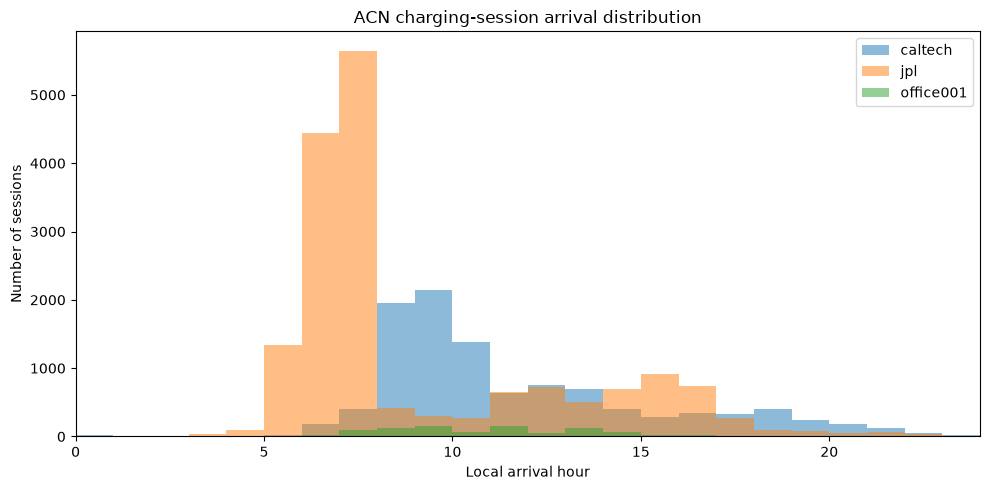

Saved: Figures/acn_arrival_distribution.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

for site, site_frame in cleaned.groupby("site"):
    ax.hist(
        site_frame["arrival_hour"],
        bins=np.arange(0, 25, 1),
        alpha=0.5,
        label=site,
    )

ax.set_xlabel("Local arrival hour")
ax.set_ylabel("Number of sessions")
ax.set_title("ACN charging-session arrival distribution")
ax.set_xlim(0, 24)
ax.legend()
fig.tight_layout()

arrival_figure = FIGURES_DIR / "acn_arrival_distribution.png"
fig.savefig(arrival_figure, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", arrival_figure.relative_to(ROOT))

## 12. Energy

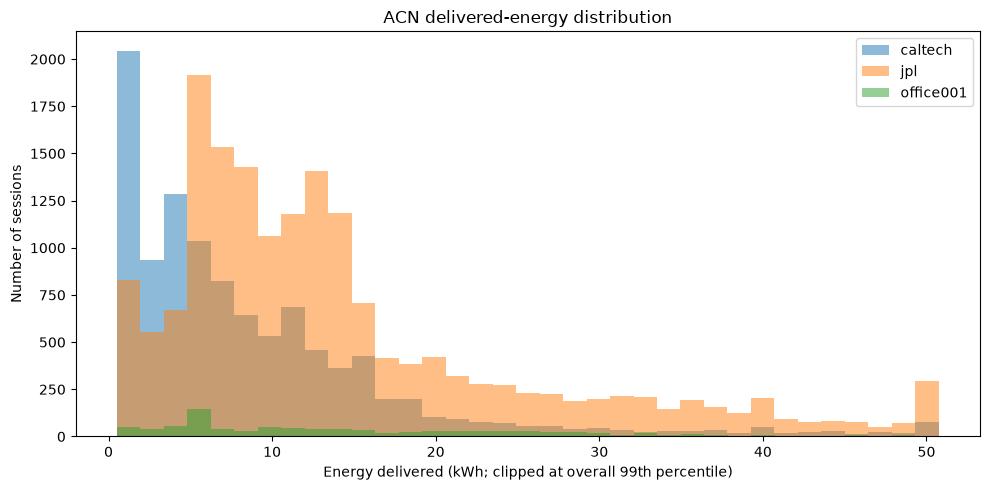

Saved: Figures/acn_energy_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

energy_upper = cleaned["energy_delivered_kwh"].quantile(0.99)

for site, site_frame in cleaned.groupby("site"):
    ax.hist(
        site_frame["energy_delivered_kwh"].clip(
            upper=energy_upper
        ),
        bins=35,
        alpha=0.5,
        label=site,
    )

ax.set_xlabel(
    "Energy delivered (kWh; clipped at overall 99th percentile)"
)
ax.set_ylabel("Number of sessions")
ax.set_title("ACN delivered-energy distribution")
ax.legend()
fig.tight_layout()

energy_figure = FIGURES_DIR / "acn_energy_distribution.png"
fig.savefig(energy_figure, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", energy_figure.relative_to(ROOT))

## 13. Flexibility Plot

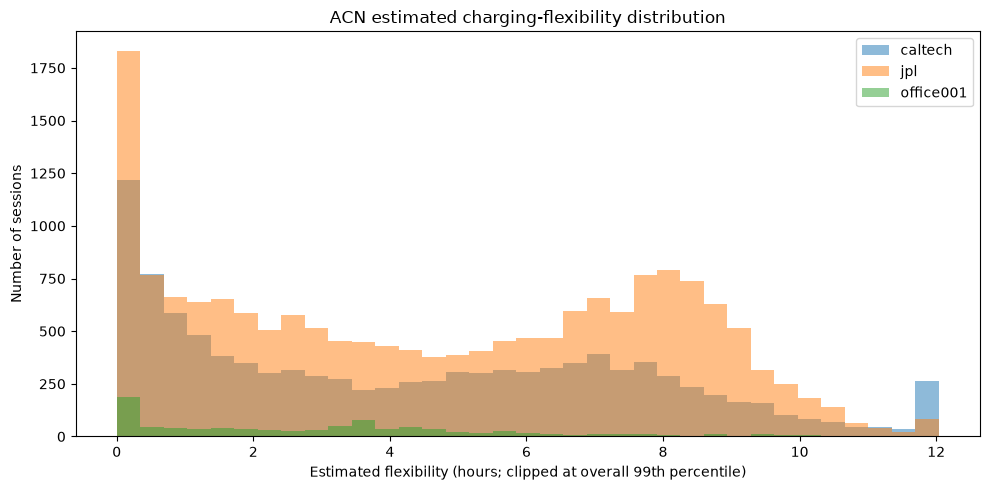

Saved: Figures/acn_flexibility_distribution.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

flexibility_upper = cleaned["flexibility_hours"].quantile(0.99)

for site, site_frame in cleaned.groupby("site"):
    ax.hist(
        site_frame["flexibility_hours"].clip(
            upper=flexibility_upper
        ),
        bins=35,
        alpha=0.5,
        label=site,
    )

ax.set_xlabel(
    "Estimated flexibility (hours; clipped at overall 99th percentile)"
)
ax.set_ylabel("Number of sessions")
ax.set_title("ACN estimated charging-flexibility distribution")
ax.legend()
fig.tight_layout()

flexibility_figure = (
    FIGURES_DIR / "acn_flexibility_distribution.png"
)
fig.savefig(
    flexibility_figure,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Saved:", flexibility_figure.relative_to(ROOT))

## 14. Final Check

In [15]:
assert cleaned["session_id"].notna().all()
assert not cleaned.duplicated(["site", "session_id"]).any()
assert cleaned["departure_utc"].gt(cleaned["arrival_utc"]).all()
assert cleaned["energy_required_kwh"].gt(0).all()
assert cleaned["dwell_hours"].between(
    MIN_DWELL_HOURS,
    MAX_DWELL_HOURS,
).all()

assert optimisation_ready["optimisation_ready"].all()

final_summary = pd.DataFrame(
    {
        "measure": [
            "Configured source period",
            "Raw sessions loaded",
            "Cleaned sessions",
            "Optimisation-ready sessions",
            "Excluded sessions",
            "Usable sites",
            "Missing sites",
            "Energy requirement policy",
            "Charging efficiency assumption",
        ],
        "value": [
            "2019 calendar year",
            f"{len(sessions):,}",
            f"{len(cleaned):,}",
            f"{len(optimisation_ready):,}",
            f"{len(excluded):,}",
            ", ".join(usable_sites),
            ", ".join(missing_sites) if missing_sites else "None",
            ENERGY_REQUIREMENT_POLICY,
            CHARGING_EFFICIENCY,
        ],
    }
)

display(final_summary)

print("Notebook ACN_Data_Cleaning_and_Flexibility completed successfully.")
print()
print("Primary input for Notebook EV_Scenario_Generation:")
print(saved_outputs["optimisation_ready"])

,measure,value
0,Configured source period,2019 calendar year
1,Raw sessions loaded,"28,950"
2,Cleaned sessions,"28,924"
3,Optimisation-ready sessions,"27,128"
4,Excluded sessions,26
5,Usable sites,"caltech, jpl, office001"
6,Missing sites,None
7,Energy requirement policy,delivered
8,Charging efficiency assumption,0.9


Notebook ACN_Data_Cleaning_and_Flexibility completed successfully.

Primary input for Notebook EV_Scenario_Generation:
/Users/mac/Send-Ev-Project/SEND-EV-Project/Data/ACN/processed/acn_sessions_optimisation_ready.csv


## Notes

- Input is the site CSVs from ACN_Data Acquisition.
- Delivered energy is the default target.
- Flexibility uses dwell time, charger power and efficiency.
- ACN is used for synthetic Keele scenarios, not Keele driver records.